<h1 style="color:red;">Google Play Store Analysis</h1>

## Load both datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

apps = pd.read_csv('googleplaystore.csv')
reviews = pd.read_csv('googleplaystore_user_reviews.csv')

print(apps.shape, reviews.shape)
apps.head()

(10841, 13) (64295, 5)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## Data cleaning

In [2]:
# remove duplicates
apps = apps.drop_duplicates()
apps = apps.drop_duplicates(subset='App')   # one row per app
reviews = reviews.drop_duplicates()

# known bad row in this dataset (columns shifted, Category = '1.9')
apps = apps[apps['Category'] != '1.9']

# nulls
apps = apps.dropna(subset=['Rating'])
reviews = reviews.dropna(subset=['Translated_Review'])

# fix data types
apps['Reviews'] = apps['Reviews'].astype(int)
apps['Installs'] = apps['Installs'].str.replace('[+,]', '', regex=True).astype(int)
apps['Price'] = apps['Price'].str.replace('$', '', regex=False).astype(float)

# Size -> MB
apps = apps[apps['Size'] != 'Varies with device']
def to_mb(s):
    if s.endswith('M'):
        return float(s[:-1])
    elif s.endswith('k'):
        return float(s[:-1]) / 1024
apps['Size_MB'] = apps['Size'].apply(to_mb)

apps.info()

<class 'pandas.DataFrame'>
Index: 7027 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             7027 non-null   str    
 1   Category        7027 non-null   str    
 2   Rating          7027 non-null   float64
 3   Reviews         7027 non-null   int64  
 4   Size            7027 non-null   str    
 5   Installs        7027 non-null   int64  
 6   Type            7027 non-null   str    
 7   Price           7027 non-null   float64
 8   Content Rating  7027 non-null   str    
 9   Genres          7027 non-null   str    
 10  Last Updated    7027 non-null   str    
 11  Current Ver     7023 non-null   str    
 12  Android Ver     7025 non-null   str    
 13  Size_MB         7027 non-null   float64
dtypes: float64(3), int64(2), str(9)
memory usage: 1.4 MB


Apps with missing ratings and apps with "Varies with device" size were removed during cleaning, leaving 7,027 apps for analysis. All category counts, percentages and visualizations below are based on this cleaned dataset.

## Category analysis

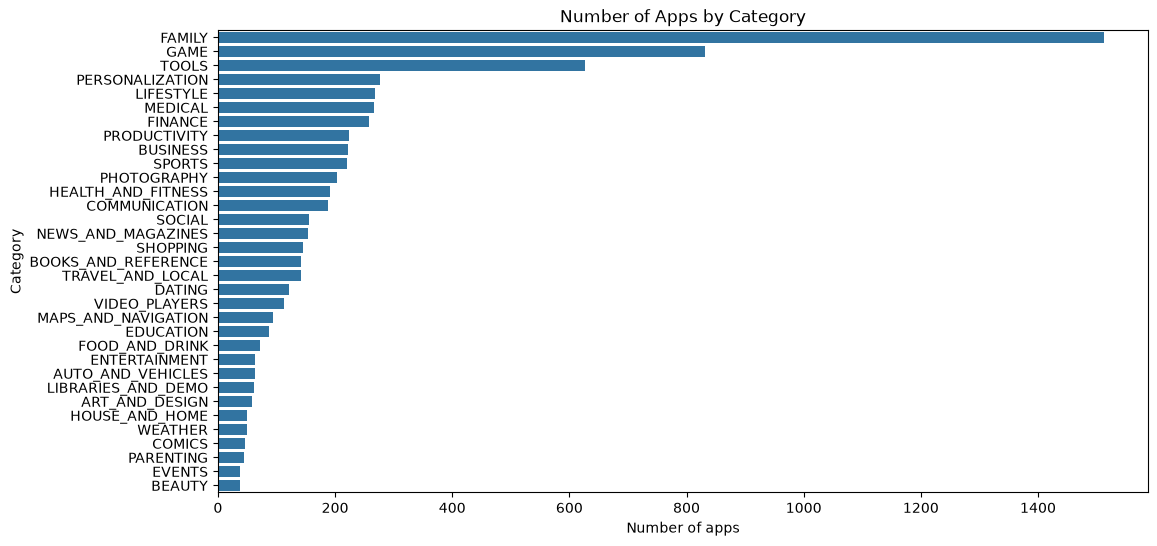

Category
FAMILY             1512
GAME                832
TOOLS               626
PERSONALIZATION     276
LIFESTYLE           269
Name: count, dtype: int64

In [3]:
cat_counts = apps['Category'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=cat_counts.values, y=cat_counts.index)
plt.title('Number of Apps by Category')
plt.xlabel('Number of apps')
plt.show()

cat_counts.head(5)   # most saturated categories

FAMILY has the most apps (1,512), followed by GAME (832) and TOOLS (626). These are the most saturated categories, so new developers face stronger competition there.

## Ratings analysis

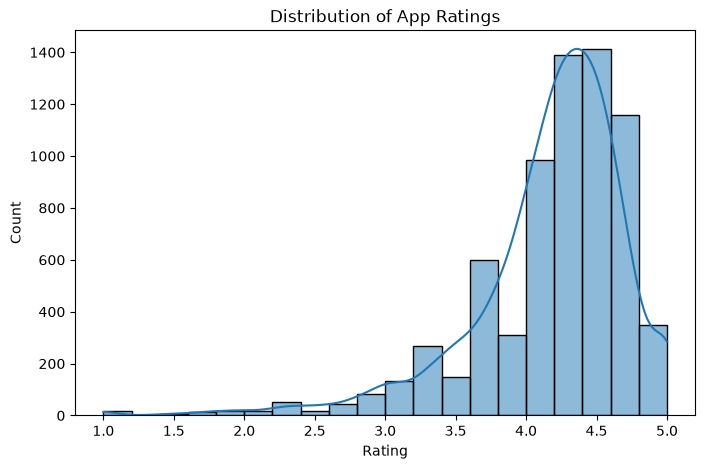

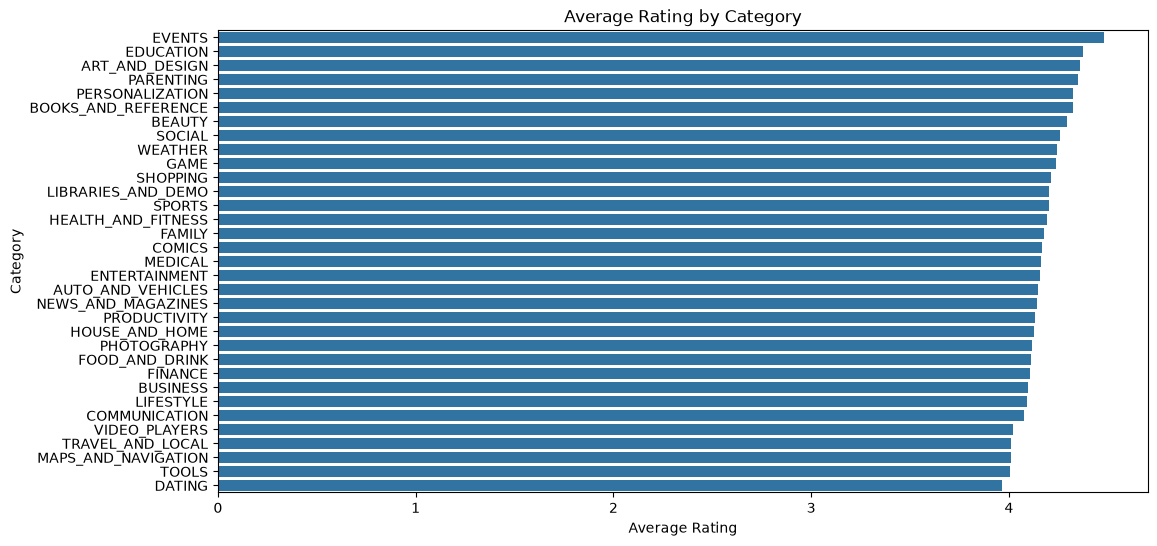

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(apps['Rating'], bins=20, kde=True)
plt.title('Distribution of App Ratings')
plt.show()

avg_rating = apps.groupby('Category')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_rating.values, y=avg_rating.index)
plt.title('Average Rating by Category')
plt.xlabel('Average Rating')
plt.show()

**Rating distribution:** Ratings are left-skewed. Most apps are rated between roughly 4 and 5, with the peak in the mid-4 range. Apps with very low ratings are rare.

**Average rating by category:** Average ratings are close across categories, all around 4 out of 5. EVENTS, EDUCATION and ART_AND_DESIGN rank highest, while DATING, TOOLS and MAPS_AND_NAVIGATION rank lowest.

## Size vs installs

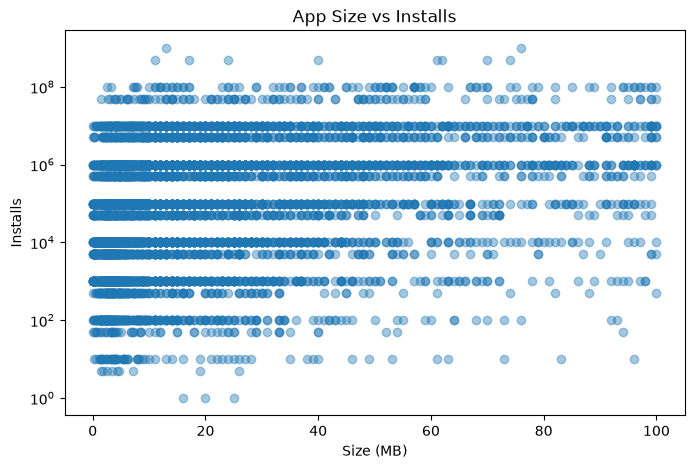

,Size_MB,Installs
Size_MB,1.000000,0.131766
Installs,0.131766,1.000000


In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(apps['Size_MB'], apps['Installs'], alpha=0.4)
plt.yscale('log')   # installs range is huge, log makes it readable
plt.xlabel('Size (MB)')
plt.ylabel('Installs')
plt.title('App Size vs Installs')
plt.show()

apps[['Size_MB', 'Installs']].corr()   # correlation value

The correlation between app size and installs is approximately 0.13, indicating a weak positive relationship. App size alone does not strongly influence the number of installs.

## Pricing analysis

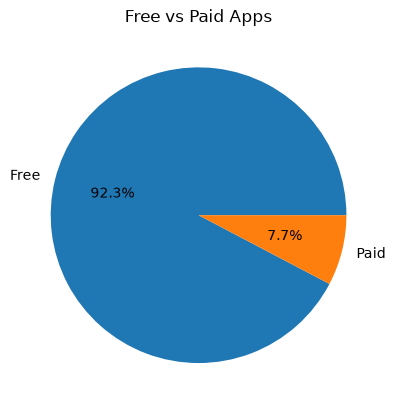

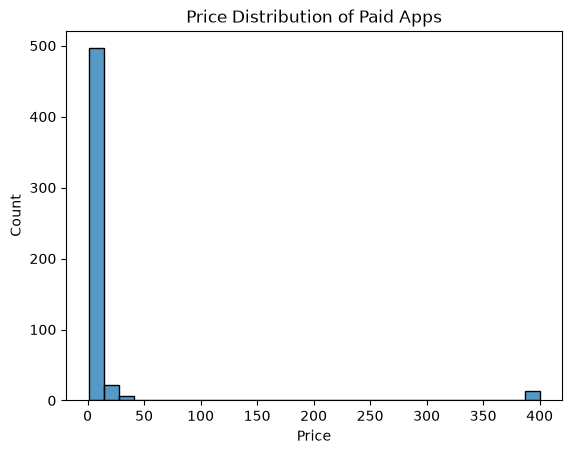

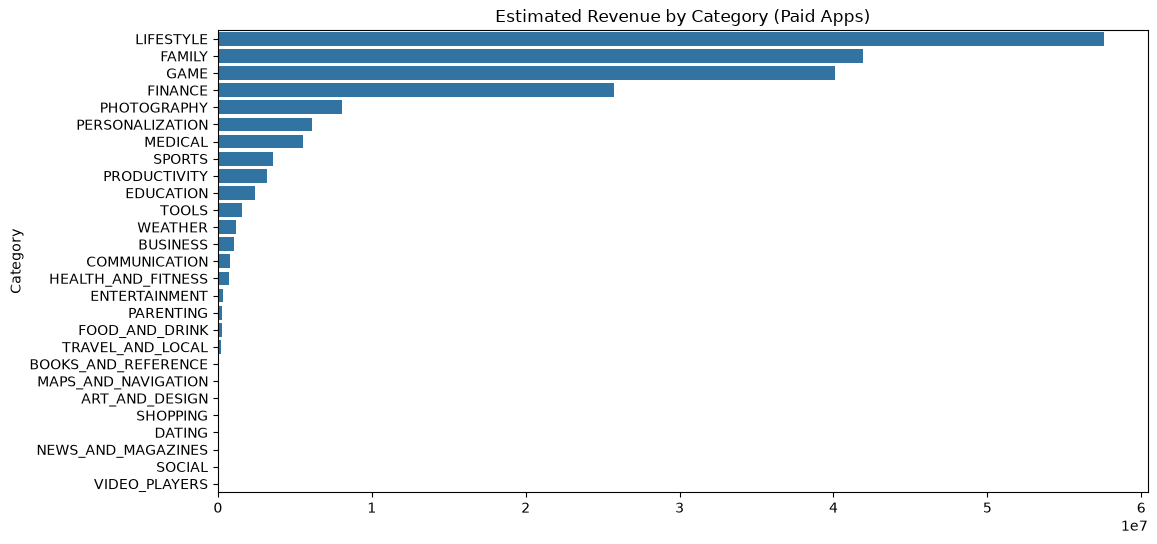

In [6]:
# paid vs free
apps['Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Free vs Paid Apps')
plt.ylabel('')
plt.show()

# price distribution for paid apps
paid = apps[apps['Type'] == 'Paid'].copy()
sns.histplot(paid['Price'], bins=30)
plt.title('Price Distribution of Paid Apps')
plt.show()

# Simple estimate: price x installs, assuming every install is a paid purchase
paid['Revenue'] = paid['Price'] * paid['Installs']
revenue_by_cat = paid.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=revenue_by_cat.values, y=revenue_by_cat.index)
plt.title('Estimated Revenue by Category (Paid Apps)')
plt.show()

**Free vs paid:** 92.3% of apps are free and only 7.7% are paid, so free or freemium models dominate the Play Store.

**Price distribution:** Most paid apps are priced at the low end of the range, but a small group of apps is priced far higher (near the $400 mark on the axis). These outliers can distort revenue estimates.

**Estimated revenue:** LIFESTYLE has the highest estimated revenue, followed by FAMILY and GAME. Revenue is calculated as Price × Installs, assuming every install is a paid purchase, so actual revenue is likely lower. A few very high-priced apps may disproportionately influence these category-level estimates.

## Sentiment analysis (VADER)

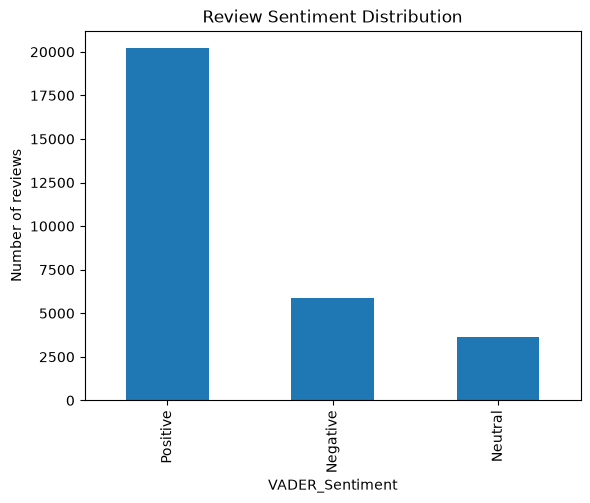

In [7]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

reviews['VADER_Sentiment'] = reviews['Translated_Review'].apply(get_sentiment)

reviews['VADER_Sentiment'].value_counts().plot(kind='bar')
plt.title('Review Sentiment Distribution')
plt.ylabel('Number of reviews')
plt.show()

Positive reviews form by far the largest group, well ahead of negative reviews, while neutral reviews are the smallest group. Overall user sentiment is favourable.

## Sentiment by category

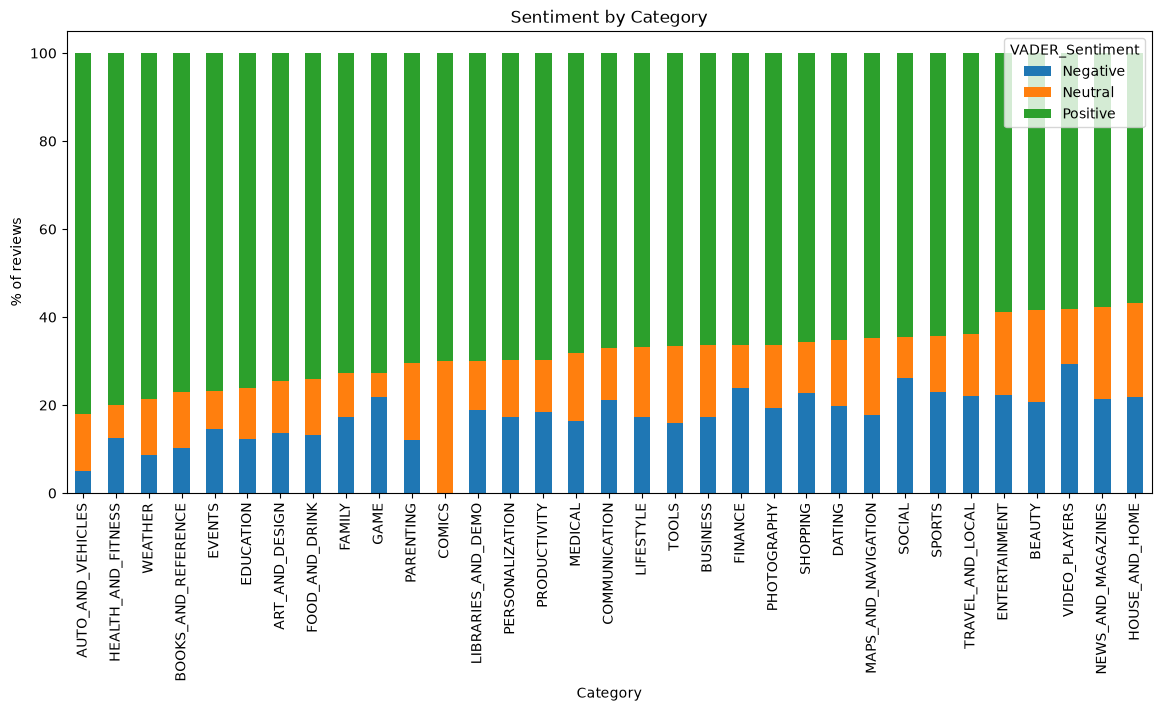

VADER_Sentiment,Negative,Neutral,Positive
Category,,,
AUTO_AND_VEHICLES,4.938272,12.962963,82.098765
HEALTH_AND_FITNESS,12.574850,7.356715,80.068435
WEATHER,8.737864,12.621359,78.640777


VADER_Sentiment,Negative,Neutral,Positive
Category,,,
VIDEO_PLAYERS,29.381443,12.371134,58.247423
SOCIAL,26.129032,9.354839,64.516129
FINANCE,23.996176,9.751434,66.252390


In [8]:
merged = reviews.merge(apps[['App', 'Category']], on='App')

sent_cat = pd.crosstab(merged['Category'], merged['VADER_Sentiment'], normalize='index') * 100

sent_cat.sort_values('Positive', ascending=False).plot(kind='bar', stacked=True, figsize=(14, 6))
plt.ylabel('% of reviews')
plt.title('Sentiment by Category')
plt.show()

display(sent_cat.sort_values('Positive', ascending=False).head(3))   # most positive
display(sent_cat.sort_values('Negative', ascending=False).head(3))   # most negative

AUTO_AND_VEHICLES, HEALTH_AND_FITNESS and WEATHER have the highest share of positive reviews (about 79 to 82%). VIDEO_PLAYERS, SOCIAL and FINANCE have the highest share of negative reviews (about 24 to 29%). Categories with few reviews can show extreme percentages, so read them with caution.

## Interactive plotly chart

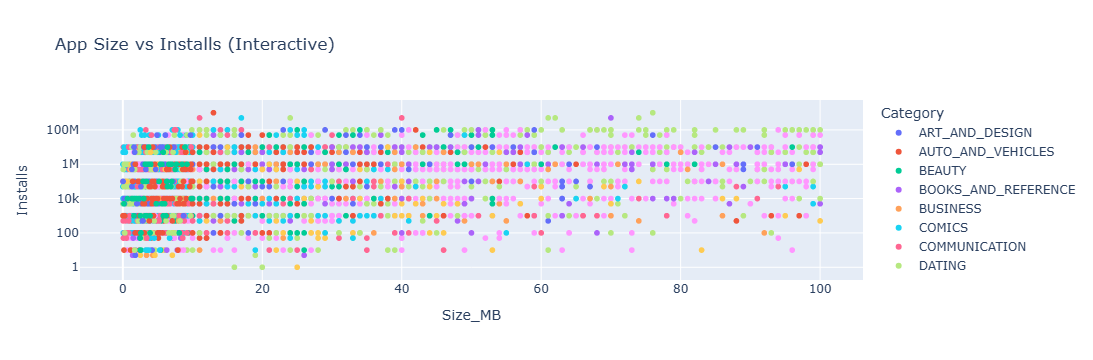

In [9]:
import plotly.express as px

fig = px.scatter(apps, x='Size_MB', y='Installs', color='Category',
                 hover_name='App', log_y=True,
                 title='App Size vs Installs (Interactive)')
fig.show()

## Conclusion: 3 insights for a developer launching a new app

1.**Category Saturation**

- FAMILY (1512 apps), GAME (832 apps), and TOOLS (626 apps) are the most crowded categories.

- Developers entering these categories may face stronger competition and should focus on unique features or niche audiences.

2.**Pricing Trends**

- Around 92.3% of apps are free, while only 7.7% are paid.

- A free or freemium model may help attract more users in the Play Store ecosystem.

3.**User Sentiment**

- AUTO_AND_VEHICLES has the highest share of positive reviews (~82%), while VIDEO_PLAYERS (~29%), SOCIAL (~26%) and FINANCE (~24%) have the highest share of negative reviews. 

- Categories with higher negative sentiment may indicate unmet user needs, creating opportunities for developers to differentiate their apps through improved usability, performance and user experience. 

- Categories with relatively few reviews may show more extreme percentages and should be interpreted with caution.